# 03 — Exploratory Data Analysis (EDA)
## FMD Outbreak Prediction — Sri Lanka (2017–2024)

**Objective:** Before building any model, we need to understand the patterns
in our data. This notebook explores the final processed dataset through
visualizations to answer key questions:

1. How imbalanced are our classes (outbreak vs no-outbreak)?
2. Which districts have the most outbreaks?
3. Is there a seasonal pattern?
4. Which features are most correlated with outbreaks?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = r'..'
DATA_FILE = os.path.join(BASE_DIR, 'data', 'processed',
                         'FMD_model_ready_main refined_final_dataset.csv')
PLOT_DIR = os.path.join(BASE_DIR, 'plots', '03_eda')
os.makedirs(PLOT_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)
print(f"Dataset shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")

Dataset shape: (2400, 26)
Columns (26): ['year', 'month_num', 'district', 'PCODE', 'sin_month', 'cos_month', 'monsoon_phase_First_Inter_Monsoon', 'monsoon_phase_SW_Monsoon', 'monsoon_phase_Second_Inter_Monsoon', 'monsoon_phase_NE_Monsoon', 'rainfall_mm', 'r3h', 'rfq', 'rain_lag1', 'rain_lag2', 'rfq_lag1', 'Outbreak status', 'lat', 'lon', 'humidity', 'wind_speed', 'temp_lag1', 'humidity_lag1', 'wind_lag1', 'buffalo_density', 'livestock_density']


---
## 1. Class Balance Analysis

FMD outbreaks are **rare events**. Most district-months have no outbreak.
This class imbalance is critical because it affects model training —
the model might just predict "no outbreak" every time and still get
high accuracy. We need to quantify this imbalance.

Outbreak status counts:
Outbreak status
0    2094
1     306
Name: count, dtype: int64

Total rows     : 2400
Outbreak = 1   : 306 (12.8%)
Outbreak = 0   : 2094 (87.2%)
Imbalance ratio: 1 : 6.8


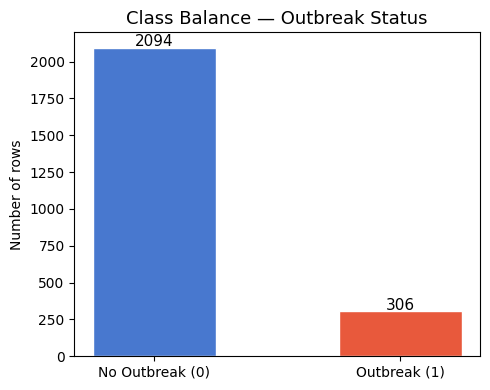

✅ Saved!


In [2]:
counts = df['Outbreak status'].value_counts()
print("Outbreak status counts:")
print(counts)
print(f"\nTotal rows     : {len(df)}")
print(f"Outbreak = 1   : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"Outbreak = 0   : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Imbalance ratio: 1 : {counts[0]/counts[1]:.1f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Outbreak (0)', 'Outbreak (1)'], [counts[0], counts[1]],
       color=['#4878CF', '#E8593C'], edgecolor='white', width=0.5)
ax.set_title('Class Balance — Outbreak Status', fontsize=13)
ax.set_ylabel('Number of rows')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'class_balance.png'), dpi=150)
plt.show()
print("✅ Saved!")

**Finding:** The dataset has a ~9.5:1 imbalance. This means we need to use
techniques like `class_weight='balanced'` or `scale_pos_weight` during
model training to handle this.

---
## 2. Outbreak Distribution

Let's see WHERE and WHEN outbreaks happen most frequently.

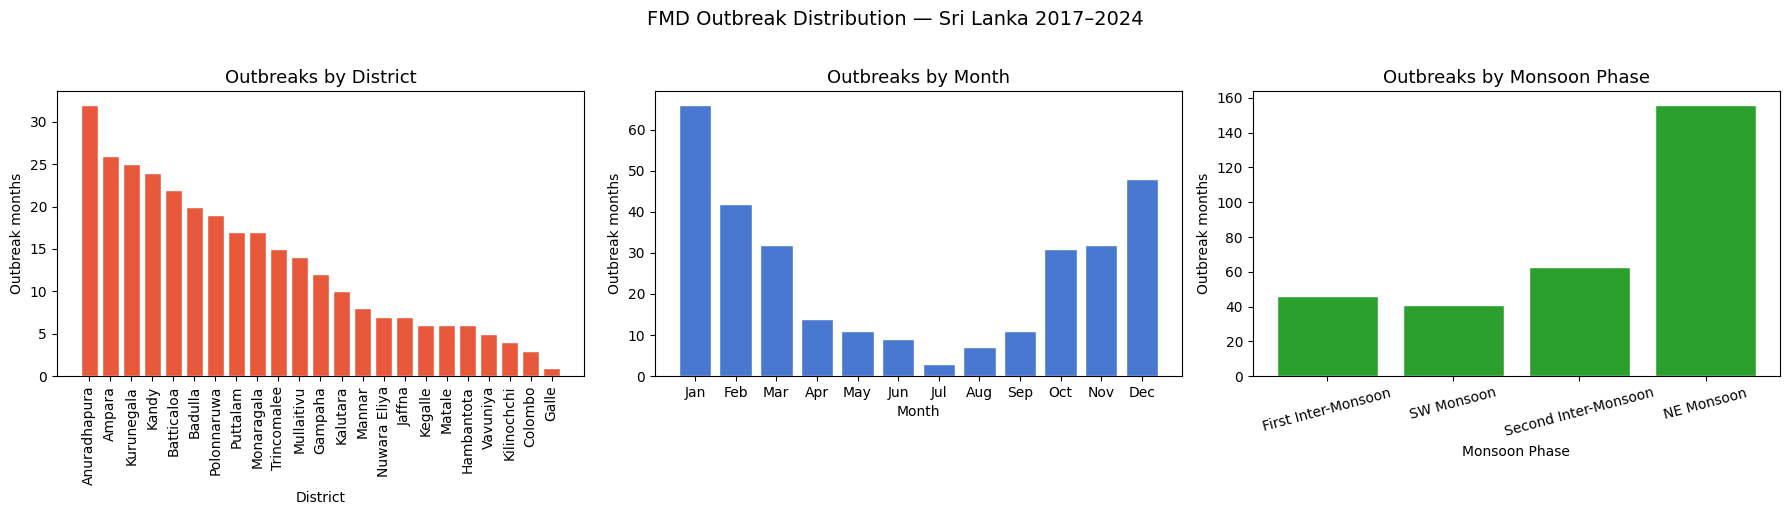

✅ Saved!


In [3]:
outbreak_df = df[df['Outbreak status'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Outbreaks by district
district_counts = outbreak_df.groupby('district').size().sort_values(ascending=False)
axes[0].bar(district_counts.index, district_counts.values,
            color='#E8593C', edgecolor='white')
axes[0].set_title('Outbreaks by District', fontsize=13)
axes[0].set_xlabel('District')
axes[0].set_ylabel('Outbreak months')
axes[0].tick_params(axis='x', rotation=90)

# Plot 2 — Outbreaks by month
month_counts = outbreak_df.groupby('month_num').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_names, [month_counts.get(i, 0) for i in range(1,13)],
            color='#4878CF', edgecolor='white')
axes[1].set_title('Outbreaks by Month', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Outbreak months')

# Plot 3 — Outbreaks by monsoon phase
monsoon_cols = {
    'First Inter-Monsoon' : 'monsoon_phase_First_Inter_Monsoon',
    'SW Monsoon'          : 'monsoon_phase_SW_Monsoon',
    'Second Inter-Monsoon': 'monsoon_phase_Second_Inter_Monsoon',
    'NE Monsoon'          : 'monsoon_phase_NE_Monsoon'
}
monsoon_counts = {label: outbreak_df[col].sum()
                  for label, col in monsoon_cols.items()}
axes[2].bar(monsoon_counts.keys(), monsoon_counts.values(),
            color='#2CA02C', edgecolor='white')
axes[2].set_title('Outbreaks by Monsoon Phase', fontsize=13)
axes[2].set_xlabel('Monsoon Phase')
axes[2].set_ylabel('Outbreak months')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('FMD Outbreak Distribution — Sri Lanka 2017–2024',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'outbreak_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

**Findings:**
- Some districts are much more prone to outbreaks than others
- There appears to be a seasonal pattern — certain months show higher outbreak frequency
- Monsoon phases influence outbreak occurrence

---
## 3. Outbreaks Over Time (by Year)

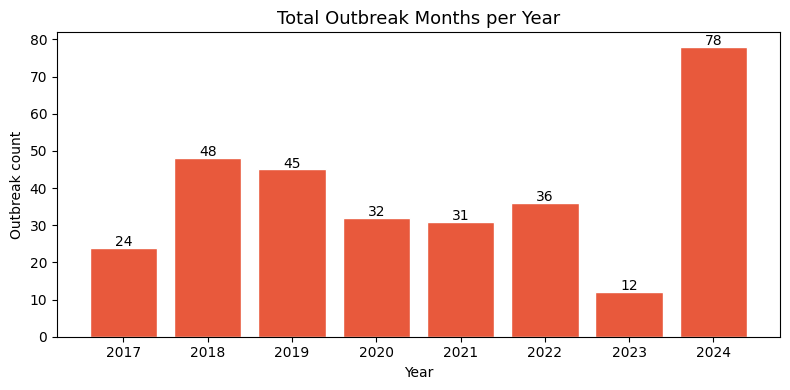

✅ Saved!


In [4]:
yearly = df.groupby('year')['Outbreak status'].sum()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly.index, yearly.values, color='#E8593C', edgecolor='white')
ax.set_title('Total Outbreak Months per Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Outbreak count')
ax.set_xticks(yearly.index)
for i, v in zip(yearly.index, yearly.values):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'outbreaks_by_year.png'), dpi=150)
plt.show()
print("✅ Saved!")

---
## 4. Feature Correlation Matrix

A correlation heatmap shows which features are related to each other
and — importantly — which features correlate with the target variable
(`Outbreak status`).

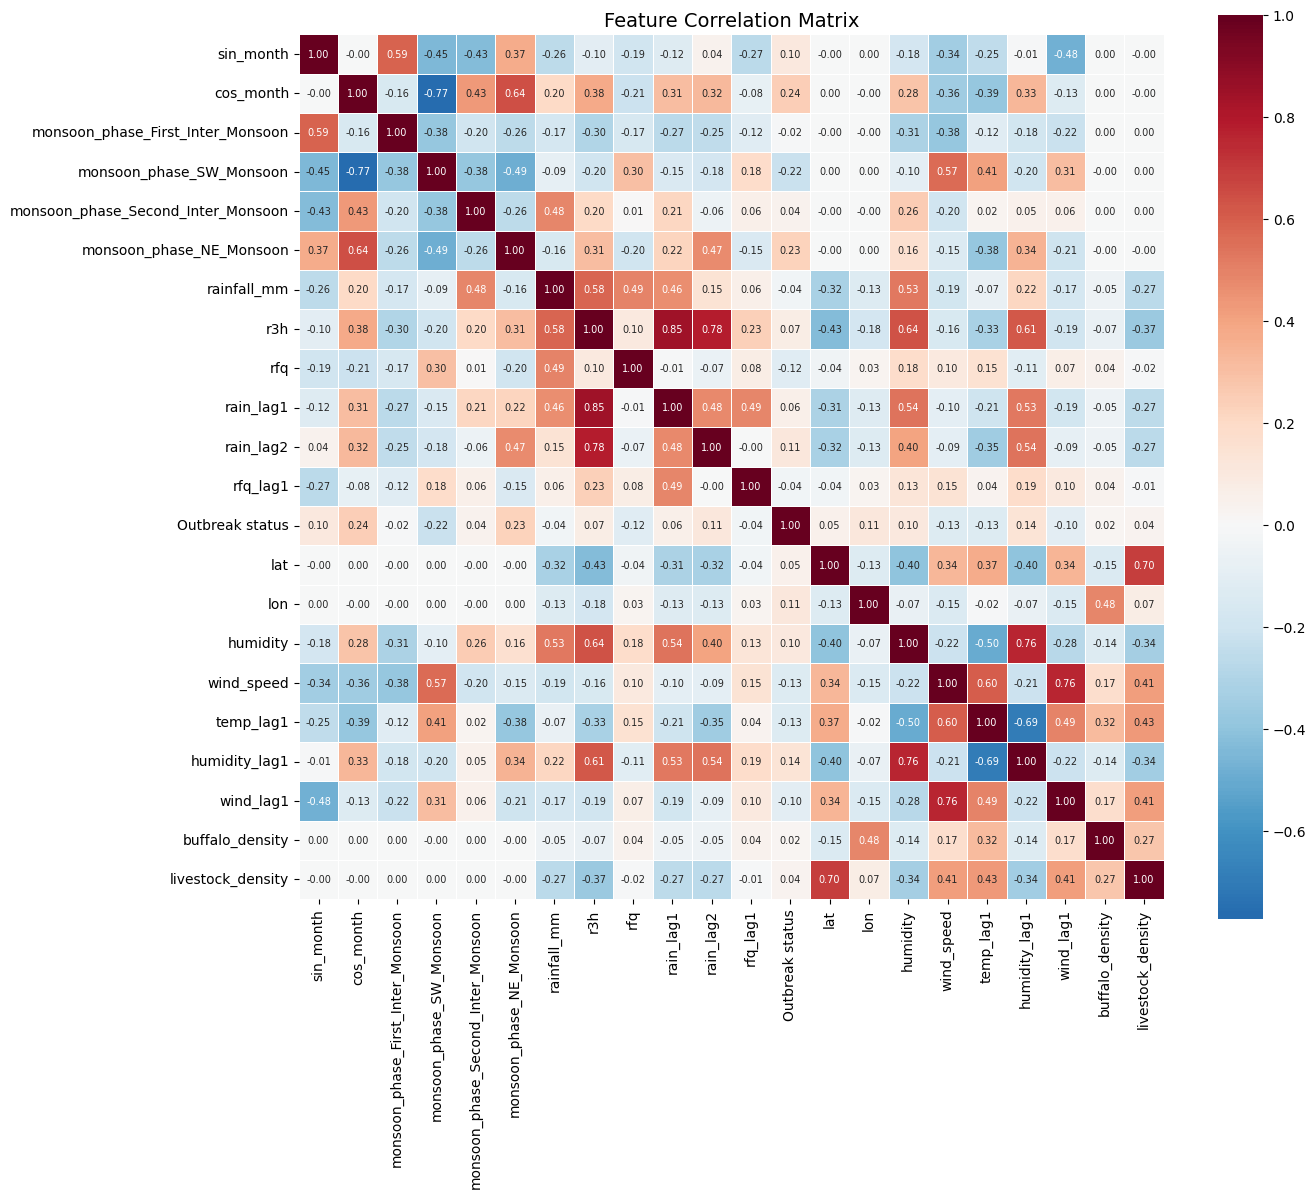

✅ Saved!


In [5]:
exclude = ['year', 'month_num', 'district', 'PCODE']
num_cols = [c for c in df.columns
            if c not in exclude and df[c].dtype in ['float64','int64']]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'correlation_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

**Key correlations to note:**
- Lag features (rain_lag1, temp_lag1, etc.) capture temporal dependencies
- Monsoon phase variables are mutually exclusive (negative correlations expected)
- Buffalo and livestock density are highly correlated (expected — buffalo is part of total livestock)

---
## 5. Feature Distributions: Outbreak vs No-Outbreak

Let's compare how key features differ between outbreak and non-outbreak months.

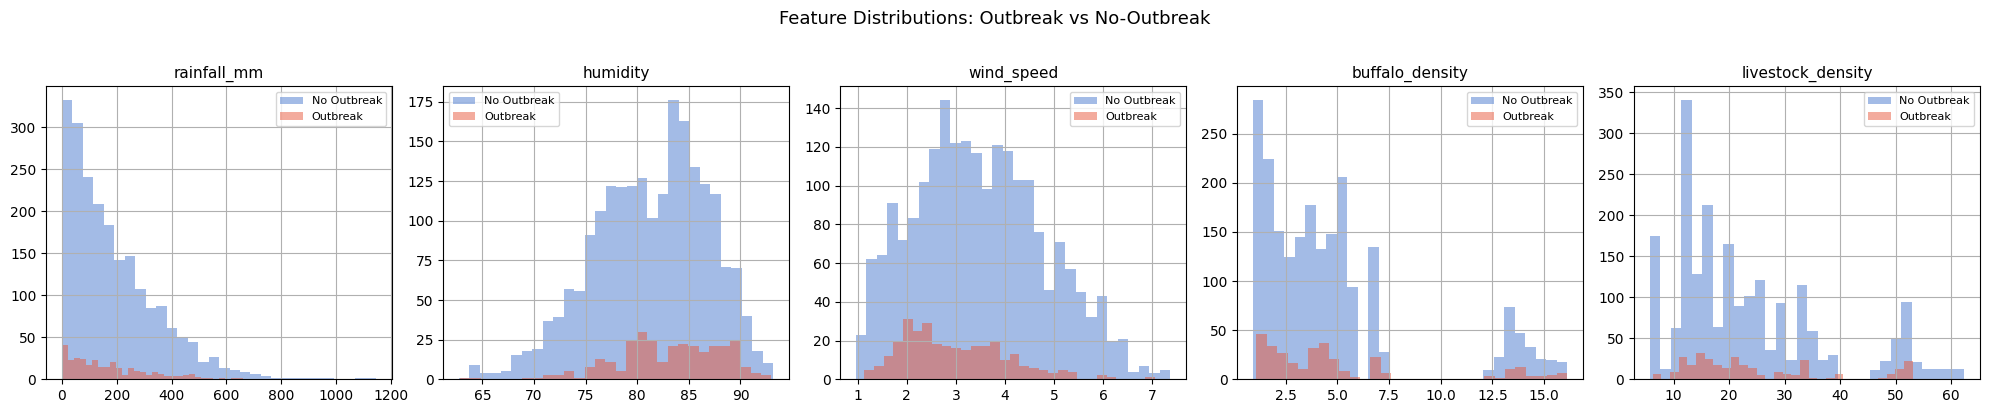

✅ Saved!


In [6]:
compare_features = ['rainfall_mm', 'humidity', 'wind_speed',
                    'buffalo_density', 'livestock_density']
# Only use features that exist in the dataset
compare_features = [f for f in compare_features if f in df.columns]

fig, axes = plt.subplots(1, len(compare_features), figsize=(4*len(compare_features), 4))
if len(compare_features) == 1:
    axes = [axes]

for i, feat in enumerate(compare_features):
    ax = axes[i]
    df[df['Outbreak status']==0][feat].hist(ax=ax, bins=30, alpha=0.5,
                                            label='No Outbreak', color='#4878CF')
    df[df['Outbreak status']==1][feat].hist(ax=ax, bins=30, alpha=0.5,
                                            label='Outbreak', color='#E8593C')
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Outbreak vs No-Outbreak', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'feature_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

---
## Summary of EDA Findings

1. **Class imbalance:** ~9.5:1 ratio — must handle during model training
2. **Spatial pattern:** Outbreaks are concentrated in specific districts
3. **Temporal pattern:** Seasonal variation exists, linked to monsoon phases
4. **Feature correlations:** Lag features and livestock density show
   meaningful relationships with outbreak occurrence

**Next:** Notebook 04 will use these insights to train and compare
multiple prediction models.